# Aggregate Results Plots

Use this notebook after experiments have finished. It imports `scripts.aggregate_results`, displays seed-aggregated training curves inline, and can optionally save the figures and CSV summaries.

## Setup

Run this from the repository root locally. In Colab, clone or mount the repository first, then adjust `REPO_ROOT` if your checkout lives somewhere else.

In [ ]:
%pwd

In [ ]:
REPO_ROOT

In [25]:
REPO_ROOT = Path('/Users/dhillo/Garage/Quant/Reinforcement Learning/trpo_latest_code 2/trpo/')

In [26]:
%matplotlib inline

from pathlib import Path
import os
import sys

#REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "scripts" / "aggregate_results.py").exists():
    for candidate in [Path("/content/trpo"), Path("/content/drive/MyDrive/trpo")]:
        if (candidate / "scripts" / "aggregate_results.py").exists():
            REPO_ROOT = candidate.resolve()
            break

if not (REPO_ROOT / "scripts" / "aggregate_results.py").exists():
    raise FileNotFoundError("Set REPO_ROOT to the checkout that contains scripts/aggregate_results.py")

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Using repository: {REPO_ROOT}")

Using repository: /Users/dhillo/Garage/Quant/Reinforcement Learning/trpo_latest_code 2/trpo


In [27]:
import importlib
import scripts.aggregate_results as aggregate_results

# Reload the module so notebook kernels pick up recent edits to scripts/aggregate_results.py.
aggregate_results = importlib.reload(aggregate_results)
from scripts.aggregate_results import discover_run_groups, plot_aggregate_results

## Plot Options

Set `SAVE_FIGURES = True` to write report-ready figures. PDF is the default here because it stays sharp in modern LaTeX and preserves transparency better than EPS.

In [28]:
OUTPUTS_ROOT = REPO_ROOT / "outputs"

METRIC = "train_return_mean"
X_AXIS = "epoch"
SMOOTH_WINDOW = 1
INTERVAL = "std"  # choices: "std", "sem", "ci95", "none"

SAVE_FIGURES = True
SAVE_FORMATS = ["pdf"]  # Use ["png", "pdf"] if you also want quick preview images.
SAVE_DIR = REPO_ROOT / "report" / "figures"

## Available Runs

In [29]:
catalog = discover_run_groups(OUTPUTS_ROOT)
display(catalog[["run_name", "env_id", "suite", "method", "method_variant", "num_seeds", "completed_epochs"]])

,run_name,env_id,suite,method,method_variant,num_seeds,completed_epochs
0,beamrider_ppo_clip,ALE/BeamRider-v5,atari,ppo,clip,1,300.0
1,beamrider_single_path,ALE/BeamRider-v5,atari,trpo,trpo_paper,1,300.0
2,enduro_ppo_clip,ALE/Enduro-v5,atari,ppo,clip,1,300.0
3,enduro_single_path,ALE/Enduro-v5,atari,trpo,trpo_paper,1,300.0
4,hopper_natural_pg,Hopper-v5,mujoco,natural_pg,trpo_paper,3,200.0
5,hopper_natural_pg_3x,Hopper-v5,mujoco,natural_pg,trpo_paper,2,200.0
6,hopper_natural_pg_9x,Hopper-v5,mujoco,natural_pg,trpo_paper,2,200.0
7,hopper_ppo_clip,Hopper-v5,mujoco,ppo,clip,3,200.0
8,hopper_single_path,Hopper-v5,mujoco,trpo,trpo_paper,3,200.0
9,pong_ppo_clip,ALE/Pong-v5,atari,ppo,clip,1,300.0


In [30]:
def existing_entries(entries):
    roots = []
    labels = []
    missing = []
    for rel_path, label in entries:
        root = REPO_ROOT / rel_path
        if root.exists():
            roots.append(root)
            labels.append(label)
        else:
            missing.append(str(rel_path))
    if missing:
        print("Skipping missing run roots:", ", ".join(missing))
    return roots, labels


def plot_many(comparisons, section_name, title_suffix):
    results = {}
    for env_id, entries in comparisons.items():
        roots, labels = existing_entries(entries)
        if not roots:
            print(f"No runs found for {env_id}; skipping.")
            continue
        result = plot_aggregate_results(
            roots,
            labels=labels,
            metric=METRIC,
            x_axis=X_AXIS,
            title=f"{env_id}: {title_suffix}",
            smooth_window=SMOOTH_WINDOW,
            interval=INTERVAL,
            save=SAVE_FIGURES,
            save_formats=SAVE_FORMATS,
            output_dir=SAVE_DIR / section_name,
            save_summary=True,
            show=True,
        )
        results[env_id] = result
        display(result.summary)
    return results

## Locomotion: TRPO vs NPG vs PPO

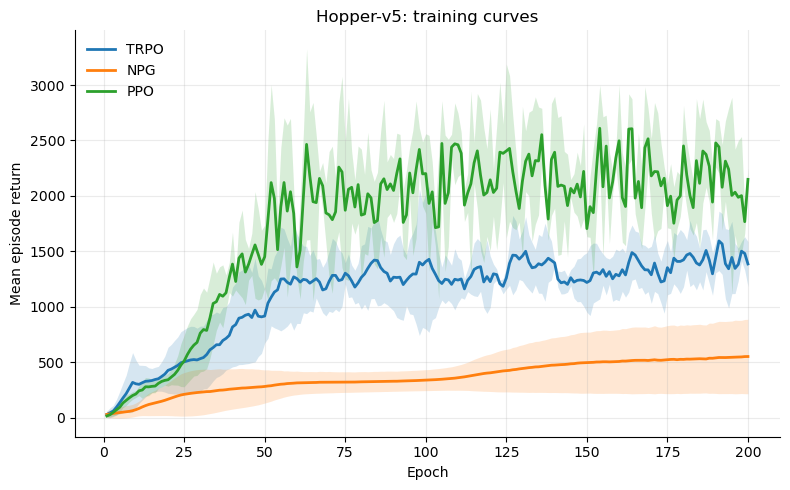

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,Hopper-v5,train_return_mean,epoch,200.0,1386.729149,202.586730,191.0,1594.577250,267.736054,3
1,NPG,Hopper-v5,train_return_mean,epoch,200.0,552.258788,335.514444,200.0,552.258788,335.514444,3
2,PPO,Hopper-v5,train_return_mean,epoch,200.0,2149.465920,102.696360,154.0,2609.998041,389.565562,3


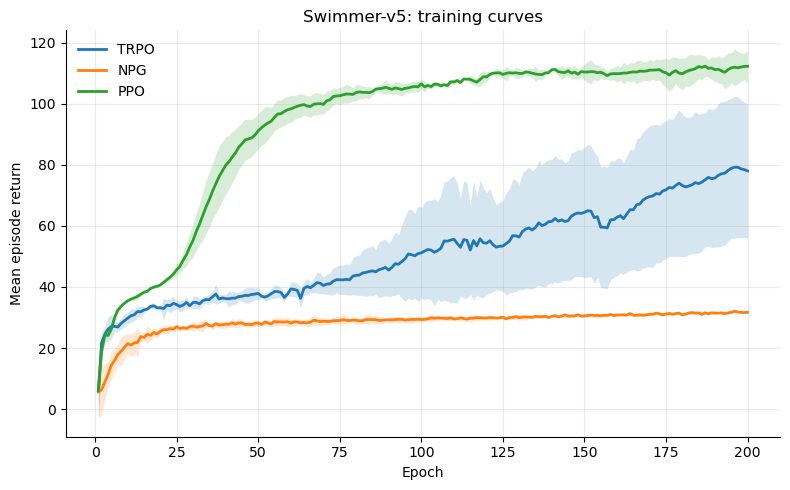

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,Swimmer-v5,train_return_mean,epoch,200.0,77.994631,21.967962,196.0,79.216283,23.293852,3
1,NPG,Swimmer-v5,train_return_mean,epoch,200.0,31.693161,0.261810,196.0,32.034166,0.394783,3
2,PPO,Swimmer-v5,train_return_mean,epoch,200.0,112.279961,5.320605,187.0,112.308127,3.377352,3


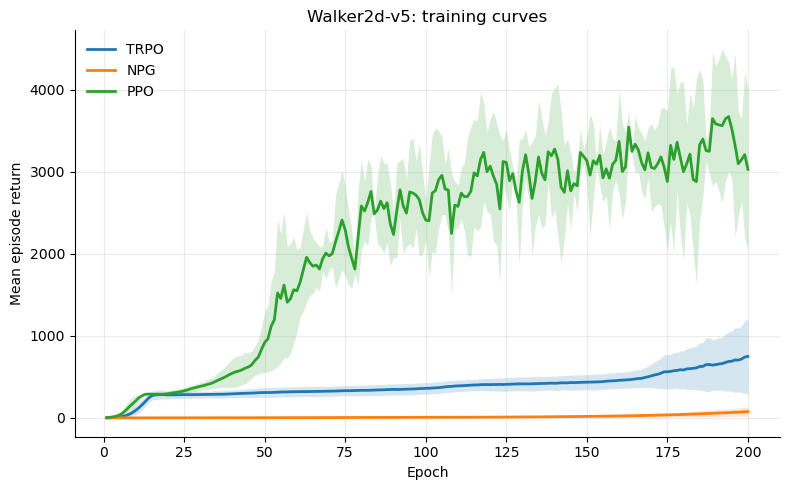

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,Walker2d-v5,train_return_mean,epoch,200.0,746.705229,458.971975,200.0,746.705229,458.971975,3
1,NPG,Walker2d-v5,train_return_mean,epoch,200.0,73.309770,56.412896,200.0,73.309770,56.412896,3
2,PPO,Walker2d-v5,train_return_mean,epoch,200.0,3027.238862,985.822404,194.0,3670.919302,667.612340,3


In [31]:
LOCOMOTION_COMPARISONS = {
    "Hopper-v5": [
        (Path("outputs/hopper_single_path"), "TRPO"),
        (Path("outputs/hopper_natural_pg"), "NPG"),
        (Path("outputs/hopper_ppo_clip"), "PPO"),
    ],
    "Swimmer-v5": [
        (Path("outputs/swimmer_single_path"), "TRPO"),
        (Path("outputs/swimmer_natural_pg"), "NPG"),
        (Path("outputs/swimmer_ppo_clip"), "PPO"),
    ],
    "Walker2d-v5": [
        (Path("outputs/walker2d_single_path"), "TRPO"),
        (Path("outputs/walker2d_natural_pg"), "NPG"),
        (Path("outputs/walker2d_ppo_clip"), "PPO"),
    ],
}

locomotion_results = plot_many(LOCOMOTION_COMPARISONS, "locomotion", "training curves")

## NPG Step-Size Ablation

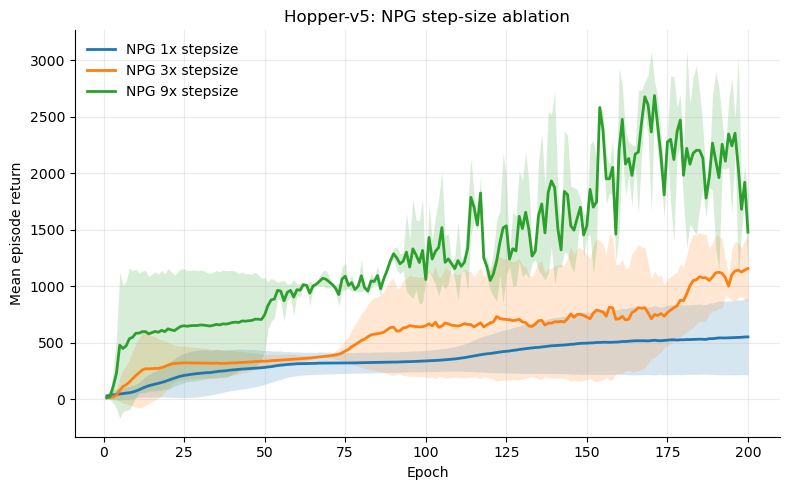

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,NPG 1x stepsize,Hopper-v5,train_return_mean,epoch,200.0,552.258788,335.514444,200.0,552.258788,335.514444,3
1,NPG 3x stepsize,Hopper-v5,train_return_mean,epoch,200.0,1156.567317,282.789411,200.0,1156.567317,282.789411,2
2,NPG 9x stepsize,Hopper-v5,train_return_mean,epoch,200.0,1478.938705,328.864055,171.0,2688.243551,127.769643,2


In [32]:
NPG_ABLATIONS = {
    "Hopper-v5": [
        (Path("outputs/hopper_natural_pg"), "NPG 1x stepsize"),
        (Path("outputs/hopper_natural_pg_3x"), "NPG 3x stepsize"),
        (Path("outputs/hopper_natural_pg_9x"), "NPG 9x stepsize"),
    ],
}

npg_ablation_results = plot_many(NPG_ABLATIONS, "npg_ablation", "NPG step-size ablation")

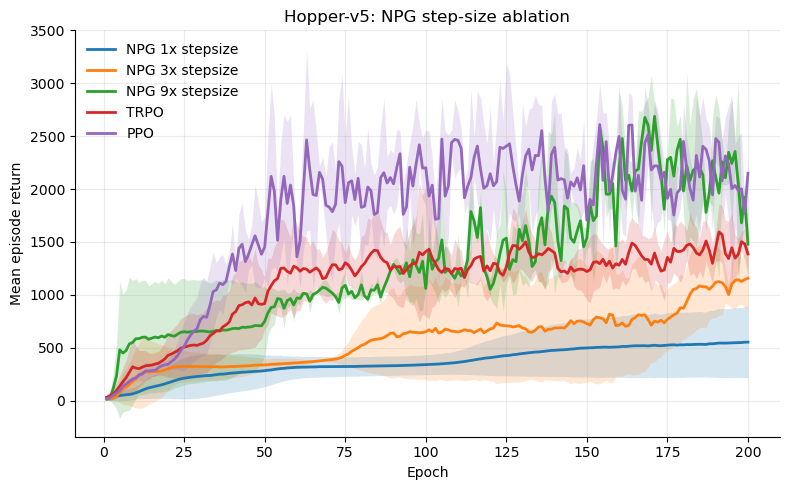

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,NPG 1x stepsize,Hopper-v5,train_return_mean,epoch,200.0,552.258788,335.514444,200.0,552.258788,335.514444,3
1,NPG 3x stepsize,Hopper-v5,train_return_mean,epoch,200.0,1156.567317,282.789411,200.0,1156.567317,282.789411,2
2,NPG 9x stepsize,Hopper-v5,train_return_mean,epoch,200.0,1478.938705,328.864055,171.0,2688.243551,127.769643,2
3,TRPO,Hopper-v5,train_return_mean,epoch,200.0,1386.729149,202.586730,191.0,1594.577250,267.736054,3
4,PPO,Hopper-v5,train_return_mean,epoch,200.0,2149.465920,102.696360,154.0,2609.998041,389.565562,3


In [33]:
NPG_ABLATIONS = {
    "Hopper-v5": [
        (Path("outputs/hopper_natural_pg"), "NPG 1x stepsize"),
        (Path("outputs/hopper_natural_pg_3x"), "NPG 3x stepsize"),
        (Path("outputs/hopper_natural_pg_9x"), "NPG 9x stepsize"),
        (Path("outputs/hopper_single_path"), "TRPO"),
        (Path("outputs/hopper_ppo_clip"), "PPO"),
    ],
}

npg_ablation_results = plot_many(NPG_ABLATIONS, "npg_ablation", "NPG step-size ablation")

## Atari Comparisons

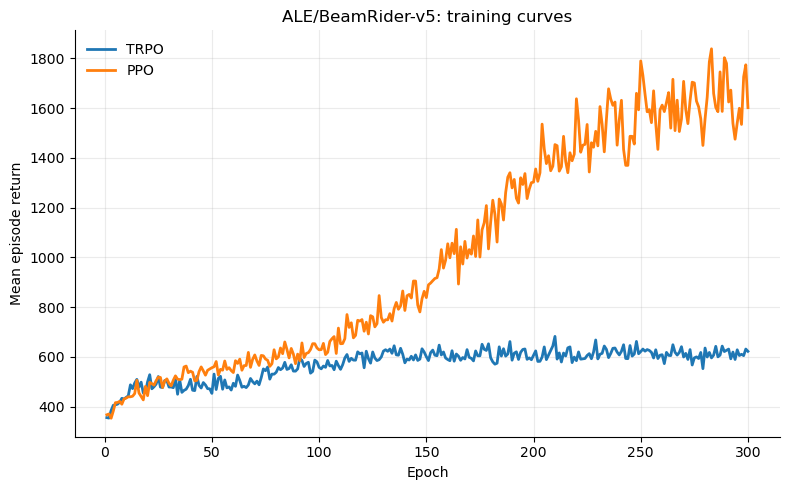

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/BeamRider-v5,train_return_mean,epoch,300.0,622.140845,NaN,210.0,682.222222,NaN,1
1,PPO,ALE/BeamRider-v5,train_return_mean,epoch,300.0,1601.707317,NaN,283.0,1838.444444,NaN,1


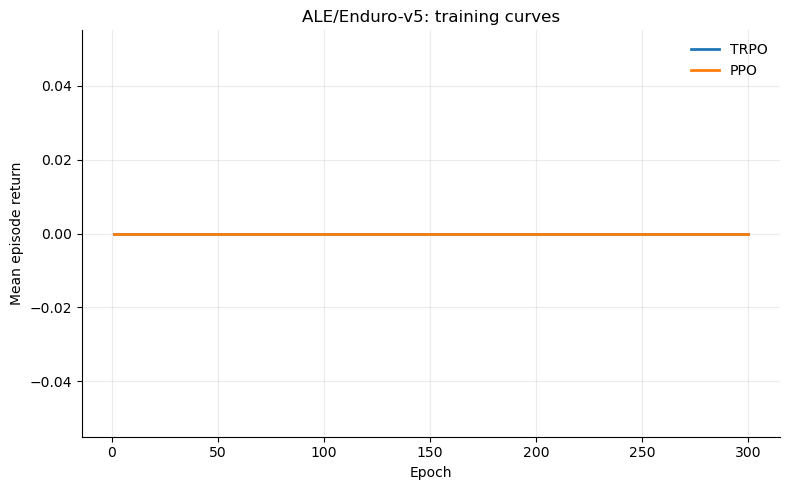

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/Enduro-v5,train_return_mean,epoch,300.0,0.0,NaN,1.0,0.0,NaN,1
1,PPO,ALE/Enduro-v5,train_return_mean,epoch,300.0,0.0,NaN,1.0,0.0,NaN,1


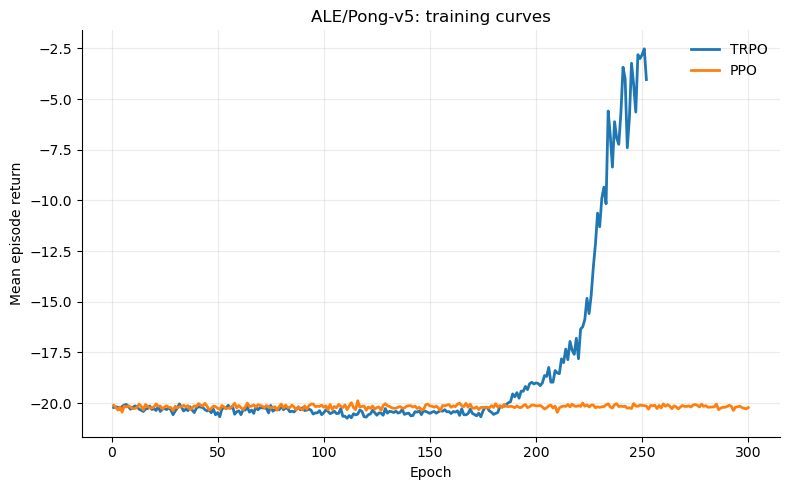

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/Pong-v5,train_return_mean,epoch,252.0,-4.038462,NaN,251.0,-2.520000,NaN,1
1,PPO,ALE/Pong-v5,train_return_mean,epoch,300.0,-20.219048,NaN,116.0,-19.882353,NaN,1


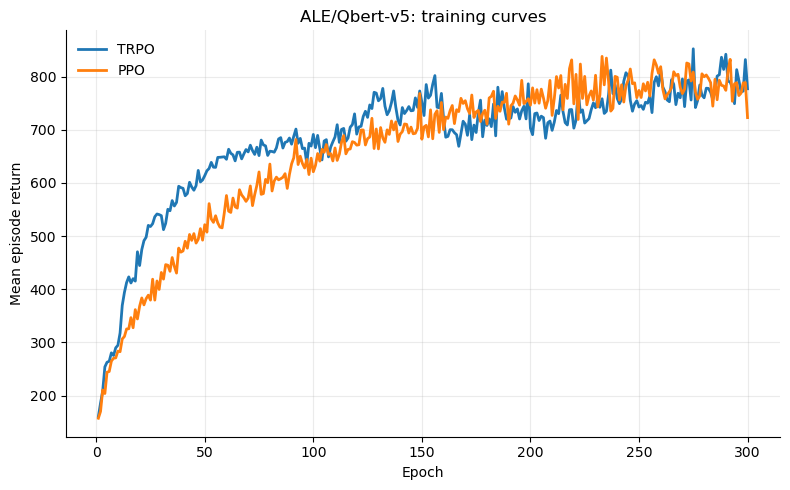

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/Qbert-v5,train_return_mean,epoch,300.0,776.963351,NaN,275.0,852.168367,NaN,1
1,PPO,ALE/Qbert-v5,train_return_mean,epoch,300.0,722.781065,NaN,233.0,837.878788,NaN,1


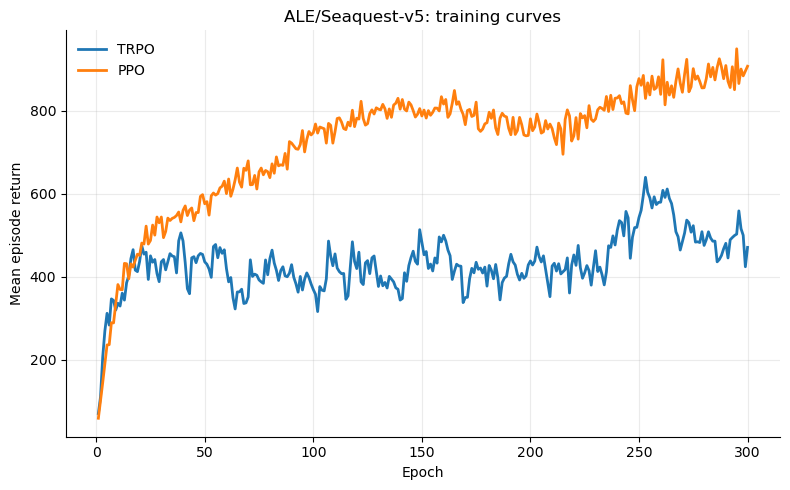

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/Seaquest-v5,train_return_mean,epoch,300.0,471.081081,NaN,253.0,640.000000,NaN,1
1,PPO,ALE/Seaquest-v5,train_return_mean,epoch,300.0,907.741935,NaN,295.0,949.830508,NaN,1


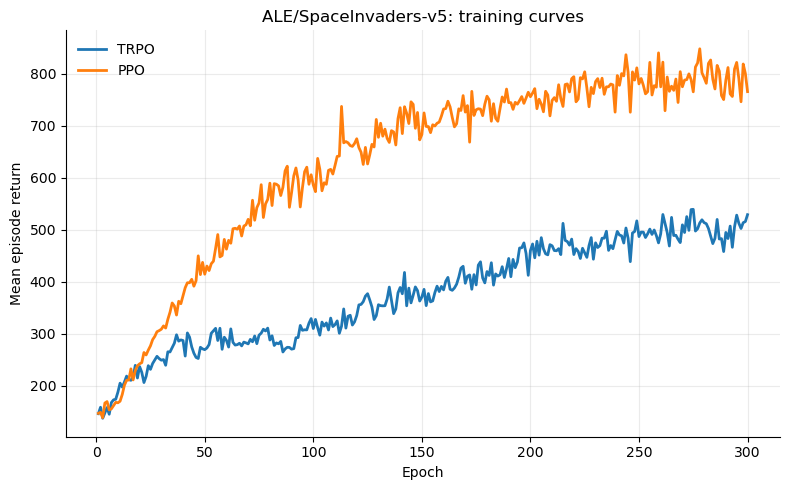

,label,env_id,metric,x_axis,final_x,final_mean,final_std,best_x,best_mean,best_std,num_seeds
0,TRPO,ALE/SpaceInvaders-v5,train_return_mean,epoch,300.0,528.945312,NaN,275.0,539.212598,NaN,1
1,PPO,ALE/SpaceInvaders-v5,train_return_mean,epoch,300.0,765.617284,NaN,278.0,848.000000,NaN,1


In [34]:
ATARI_COMPARISONS = {
    "ALE/BeamRider-v5": [
        (Path("outputs/beamrider_single_path"), "TRPO"),
        (Path("outputs/beamrider_ppo_clip"), "PPO"),
    ],
    "ALE/Enduro-v5": [
        (Path("outputs/enduro_single_path"), "TRPO"),
        (Path("outputs/enduro_ppo_clip"), "PPO"),
    ],
    "ALE/Pong-v5": [
        (Path("outputs/pong_single_path"), "TRPO"),
        (Path("outputs/pong_ppo_clip"), "PPO"),
    ],
    "ALE/Qbert-v5": [
        (Path("outputs/qbert_single_path"), "TRPO"),
        (Path("outputs/qbert_ppo_clip"), "PPO"),
    ],
    "ALE/Seaquest-v5": [
        (Path("outputs/seaquest_single_path"), "TRPO"),
        (Path("outputs/seaquest_ppo_clip"), "PPO"),
    ],
    "ALE/SpaceInvaders-v5": [
        (Path("outputs/spaceinvaders_single_path"), "TRPO"),
        (Path("outputs/spaceinvaders_ppo_clip"), "PPO"),
    ],
}

atari_results = plot_many(ATARI_COMPARISONS, "atari", "training curves")

## Custom Comparison

In [ ]:
CUSTOM_RUNS = [
    # (Path("outputs/my_trpo_run"), "TRPO"),
    # (Path("outputs/my_ppo_run"), "PPO"),
]

if CUSTOM_RUNS:
    roots, labels = existing_entries(CUSTOM_RUNS)
    custom_result = plot_aggregate_results(
        roots,
        labels=labels,
        metric=METRIC,
        x_axis=X_AXIS,
        title="Custom comparison",
        smooth_window=SMOOTH_WINDOW,
        interval=INTERVAL,
        save=SAVE_FIGURES,
        save_formats=SAVE_FORMATS,
        output_dir=SAVE_DIR / "custom",
        save_summary=True,
        show=True,
    )
    display(custom_result.summary)

## Sanity-Check Tables and Run Logistics

These cells regenerate report-style tables directly from the output folders. They are meant for audit work: final/best returns, KL diagnostics, ablation volatility, hyperparameters, runtime/CUDA details, and analytic model parameter counts.

In [ ]:
from scripts.aggregate_results import (
    collect_run_hyperparameters,
    collect_seed_run_details,
    make_atari_report_table,
    make_locomotion_report_table,
    make_npg_ablation_table,
    summarize_run_groups,
)


def dedupe_entries(*comparison_dicts):
    entries = []
    seen = set()
    for comparison in comparison_dicts:
        for group_entries in comparison.values():
            for path, label in group_entries:
                key = (str(path), label)
                if key not in seen:
                    seen.add(key)
                    entries.append((path, label))
    return entries


REPORT_RUN_GROUPS = dedupe_entries(LOCOMOTION_COMPARISONS, ATARI_COMPARISONS)
NPG_STEP_ABLATION_RUNS = [
    (Path("outputs/hopper_natural_pg"), "NPG 1x stepsize"),
    (Path("outputs/hopper_natural_pg_3x"), "NPG 3x stepsize"),
    (Path("outputs/hopper_natural_pg_9x"), "NPG 9x stepsize"),
]

In [ ]:
locomotion_report_table = make_locomotion_report_table(
    REPORT_RUN_GROUPS,
    metric=METRIC,
    x_axis=X_AXIS,
)
display(locomotion_report_table)

print(locomotion_report_table.to_latex(index=False, float_format=lambda x: f"{x:.5g}"))

In [ ]:
atari_report_table = make_atari_report_table(
    REPORT_RUN_GROUPS,
    metric=METRIC,
    x_axis=X_AXIS,
    methods=("TRPO", "PPO"),
)
display(atari_report_table)

print(atari_report_table.to_latex(index=False, float_format=lambda x: f"{x:.5g}"))

In [ ]:
npg_ablation_table = make_npg_ablation_table(
    NPG_STEP_ABLATION_RUNS,
    metric=METRIC,
    x_axis=X_AXIS,
)
display(npg_ablation_table)

print(npg_ablation_table.to_latex(index=False, float_format=lambda x: f"{x:.5g}"))

In [ ]:
all_report_runs = dedupe_entries(LOCOMOTION_COMPARISONS, ATARI_COMPARISONS, {"npg": NPG_STEP_ABLATION_RUNS})
run_hparams = collect_run_hyperparameters(
    all_report_runs,
    metric=METRIC,
    x_axis=X_AXIS,
)

summary_columns = [
    "run_name",
    "label",
    "env_id",
    "num_seeds",
    "target_epochs",
    "completed_epochs_min",
    "completed_epochs_max",
    "steps_per_epoch",
    "gamma",
    "lam",
    "max_kl_config",
    "npg_stepsize",
    "ppo_clip_ratio",
    "ppo_pi_lr",
    "ppo_vf_lr",
    "ppo_entropy_coef",
    "policy_param_count",
    "value_param_count",
    "total_param_count",
    "cuda_device_name",
]
display(run_hparams[[column for column in summary_columns if column in run_hparams.columns]])

In [ ]:
seed_details = collect_seed_run_details(
    all_report_runs,
    metric=METRIC,
    x_axis=X_AXIS,
)

seed_detail_columns = [
    "run_name",
    "label",
    "env_id",
    "seed",
    "completed_epochs",
    "final_return",
    "best_return",
    "mean_kl",
    "min_kl",
    "max_kl",
    "kl_gt_threshold_pct",
    "mean_abs_return_delta",
    "total_env_steps",
    "device",
    "cuda_device_name",
]
display(seed_details[[column for column in seed_detail_columns if column in seed_details.columns]])

In [ ]:
CUSTOM_AUDIT_RUNS = [
    # (Path("outputs/my_new_run"), "My method"),
]

if CUSTOM_AUDIT_RUNS:
    display(summarize_run_groups(CUSTOM_AUDIT_RUNS, metric=METRIC, x_axis=X_AXIS))
    display(collect_run_hyperparameters(CUSTOM_AUDIT_RUNS, metric=METRIC, x_axis=X_AXIS))
    display(collect_seed_run_details(CUSTOM_AUDIT_RUNS, metric=METRIC, x_axis=X_AXIS))